# Detecting and identifying fishing vessels with Sentinel-2 + Global Fishing Watch

This notebook finds vessels in a Sentinel-2 scene over an area of interest (AOI), lets you choose which ones to investigate, and cross-checks them against **Global Fishing Watch (GFW)** AIS data to label each detection with its vessel name - or flag it as **DARK** (visible in the image, but with no matching AIS signal).

## Recommended workflow

1. **Scout in Copernicus Browser.** Open your area and date in the [Copernicus Browser](https://browser.dataspace.copernicus.eu/) and look for candidate fishing vessels: bright specks, wakes, or the curved floatline of an active purse-seine set.
2. **Get your AOI.** Either read the bounding box (`min_lon, min_lat, max_lon, max_lat`) from the Browser, or draw an area and copy its **GeoJSON**.
3. **Set the AOI** in the Inputs section - `AOI_COORDS` (bbox) **or** paste the GeoJSON into `AOI_GEOJSON` - and set `ACQUISITION_DATE`.
4. **Run the notebook** top to bottom.

## Before you start

- **Sentinel Hub credentials.** Running the Credentials cell **prompts you (via `getpass`) for your CDSE OAuth `client_id` / `client_secret`**, unless the environment already has them configured. Create an OAuth client at the [CDSE dashboard](https://shapps.dataspace.copernicus.eu/dashboard/#/account/settings).
- **Global Fishing Watch API token.** You will be prompted to paste it when you run the Credentials cell (it is not stored anywhere). Get one at [globalfishingwatch.org/our-apis/tokens](https://globalfishingwatch.org/our-apis/tokens).
- **Area of interest.** A WGS84 bounding box (`AOI_COORDS`) or a GeoJSON geometry pasted from the Copernicus Browser (`AOI_GEOJSON`) - both inline, no file needed.

## Output

A NIR false-color image with each chosen detection boxed and labelled by vessel name (or DARK), plus a results table and a CSV.

## Good to know

- **Sun glint varies a lot between scenes**, so the detection thresholds usually need re-tuning per scene - use the Copernicus Browser tuning script in Section 4.
- **GFW AIS presence is aggregated to ~1 km / hourly**, so matches are neighbourhood-level (not exact positions), and AIS data lags ~96 h - use a date at least ~4 days in the past.

In [ ]:
# Utilities
import getpass
import json
import pprint
from datetime import datetime, timedelta
from math import asin, cos, radians, sin, sqrt

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy import ndimage
from scipy.spatial.distance import pdist
from sentinelhub import (
    CRS,
    BBox,
    DataCollection,
    Geometry,
    MimeType,
    SentinelHubCatalog,
    SentinelHubRequest,
    SHConfig,
    bbox_to_dimensions,
)

## 1. Credentials

Sentinel Hub credentials are **separate** from the GFW token. Running this cell **prompts you (via `getpass`) for your CDSE OAuth `client_id` and `client_secret`** - unless the environment already has them configured (a saved `SHConfig` profile, or the CDSE test pipeline, in which case no prompt appears). Create an OAuth client at the [CDSE dashboard](https://shapps.dataspace.copernicus.eu/dashboard/#/account/settings). The GFW token is entered the same way. Nothing is written to the notebook or any file.

In [ ]:
config = SHConfig()

# On the CDSE JupyterLab kernel SHConfig() may already hold your credentials. If it does not
# (or you are running elsewhere), you'll be prompted for your CDSE OAuth client id / secret.
# Create an OAuth client at https://shapps.dataspace.copernicus.eu/dashboard/#/account/settings
if not (config.sh_client_id and config.sh_client_secret):
    config.sh_client_id = getpass.getpass("Enter your SentinelHub client id")
    config.sh_client_secret = getpass.getpass("Enter your SentinelHub client secret")
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
config.sh_base_url = "https://sh.dataspace.copernicus.eu"

# Global Fishing Watch API token (entered at runtime, never stored).
# Get one at https://globalfishingwatch.org/our-apis/tokens
GFW_TOKEN = getpass.getpass("Enter your Global Fishing Watch API token")

## 2. Inputs

Set the area of interest - either a WGS84 bounding box (`AOI_COORDS`) or a GeoJSON geometry pasted from the Copernicus Browser (`AOI_GEOJSON`, which takes precedence) - and the acquisition date. Tune the detection / matching parameters if needed.

In [ ]:
# ============ USER INPUTS ============
# Area of interest - provide ONE of:
#   (A) AOI_COORDS : a WGS84 bounding box [min_lon, min_lat, max_lon, max_lat], or
#   (B) AOI_GEOJSON: a GeoJSON geometry/Feature pasted from the Copernicus Browser.
# If AOI_GEOJSON is set it takes precedence (only its bounding box is used).
AOI_COORDS = [13.157501, 35.331179, 13.296547, 35.459831]  # Strait of Sicily (example)
AOI_GEOJSON = None  # e.g. {"type": "Polygon", "coordinates": [[[lon, lat], ...]]}
ACQUISITION_DATE = (
    "2026-06-02"  # YYYY-MM-DD (use a date > ~4 days old for AIS coverage)
)

RESOLUTION_M = 10  # Sentinel-2 native resolution for B02/B03/B04/B08
MIN_CLUSTER_PX = 3  # drop ship clusters smaller than this many pixels
MAX_CLUSTER_PX = (
    2000  # drop clusters larger than this (stubborn glint patches); None to disable
)
MATCH_RADIUS_M = 1000  # AIS neighbourhood radius for vessel matching
TEMPORAL_BUFFER_H = 1  # +/- hours around the overpass time to accept AIS presence
MAX_DIM_PX = 2500  # Sentinel Hub Process API per-request dimension cap
# =====================================


def aoi_to_bbox(coords=None, geojson=None):
    """WGS84 BBox from a bounding box, or from a pasted GeoJSON geometry/Feature/FeatureCollection."""
    if geojson:
        obj = json.loads(geojson) if isinstance(geojson, str) else geojson
        if obj.get("type") == "FeatureCollection":
            geom = obj["features"][0]["geometry"]
        elif obj.get("type") == "Feature":
            geom = obj["geometry"]
        else:  # already a geometry (Polygon / MultiPolygon)
            geom = obj
        return Geometry.from_geojson(geom, crs=CRS.WGS84).bbox
    return BBox(bbox=coords, crs=CRS.WGS84)


bbox = aoi_to_bbox(AOI_COORDS, AOI_GEOJSON)
resolution = RESOLUTION_M
size = bbox_to_dimensions(bbox, resolution=resolution)

# This detector relies on the native 10 m resolution, so refuse an AOI that would
# exceed the Process API per-request dimension cap instead of downsampling it.
if max(size) > MAX_DIM_PX:
    raise ValueError(
        f"AOI is too large at {RESOLUTION_M} m: {size[0]}x{size[1]} px (max {MAX_DIM_PX}). "
        f"Draw a smaller area of interest - this detector relies on the native {RESOLUTION_M} m "
        "resolution and won't work if downsampled."
    )

print(f"AOI bbox: {bbox}")
print(f"Image size: {size} px @ {resolution} m")

## 3. Find the scene and its overpass time

Search the Catalog for a Sentinel-2 L2A scene over the AOI on the chosen date and read its exact sensing timestamp (used later to query AIS at overpass time).

In [ ]:
DATA_COLLECTION = DataCollection.SENTINEL2_L2A.define_from(
    "s2l2a", service_url=config.sh_base_url
)

catalog = SentinelHubCatalog(config=config)
day_start = ACQUISITION_DATE
day_end = (datetime.fromisoformat(ACQUISITION_DATE) + timedelta(days=1)).strftime(
    "%Y-%m-%d"
)

search = catalog.search(
    DATA_COLLECTION,
    bbox=bbox,
    time=(day_start, day_end),
    fields={
        "include": ["id", "properties.datetime", "properties.eo:cloud_cover"],
        "exclude": [],
    },
)
results = list(search)
if not results:
    raise RuntimeError(
        f"No Sentinel-2 L2A scene over the AOI on {ACQUISITION_DATE}. Try another date."
    )

for r in results:
    print(
        r["id"],
        "|",
        r["properties"]["datetime"],
        "| cloud%:",
        r["properties"].get("eo:cloud_cover"),
    )

# Use the first acquisition's exact sensing time as the overpass timestamp (UTC).
overpass_dt = datetime.fromisoformat(
    results[0]["properties"]["datetime"].replace("Z", "+00:00")
)
print()
print("Overpass timestamp (UTC):", overpass_dt.isoformat())

## 4. Detection - tune the thresholds, then run

Vessels are detected with a simple per-pixel rule: a pixel is a candidate if it is bright in NIR (B08) or SWIR (B11/B12), where open water is dark. **Sun glint changes a lot between scenes**, so you will usually need to re-tune the two thresholds for your scene.

**Tune in Copernicus Browser:** open your scene, paste the script below into *Custom script*, and adjust `SHIP_T_NIR` / `SHIP_T_SWIR`. Use `MODE = 2` to see which band fires (red = NIR, green = SWIR, yellow = both - glint tends to be red-only), then `MODE = 1` to confirm only vessels stay highlighted. Copy your final values into the `evalscript` constants in the next cell.

```js
//VERSION=3
// Paste into Copernicus Browser -> Custom script. Tune SHIP_T_* for your scene.
const MODE = 2;            // 0=true color | 1=ship overlay (red) | 2=trigger source
const WATER_MAX = 0.06;    // true-color brightness only
const GAMMA = 0.6;
const SHIP_T_NIR  = 0.065; // B08 NIR threshold      <-- tune
const SHIP_T_SWIR = 0.065; // B11/B12 SWIR threshold <-- tune

function setup() {
  return { input: ["B02","B03","B04","B08","B11","B12","dataMask"], output: { bands: 3 } };
}
function s(x){ let v=Math.max(0,Math.min(1,x/WATER_MAX)); return Math.pow(v,GAMMA); }
function nirHit(p){ return p.B08>SHIP_T_NIR; }
function swirHit(p){ return (p.B11>SHIP_T_SWIR)||(p.B12>SHIP_T_SWIR); }
function isShip(p){ return nirHit(p)||swirHit(p); }
function evaluatePixel(p){
  let tc=[s(p.B04),s(p.B03),s(p.B02)];
  if (MODE===0) return tc;
  if (MODE===1) return isShip(p)?[1,0.1,0]:[tc[0]*0.4,tc[1]*0.4,tc[2]*0.5];
  return [nirHit(p)?1:0, swirHit(p)?1:0, 0]; // MODE 2: R=NIR, G=SWIR, yellow=both
}
```

The next cell holds the same logic as a multi-output evalscript: a `truecolor` base for picking, a `shipmask` for clustering, and the raw `bands` for the size check. It also applies a **cloud mask** from the Scene Classification Layer (SCL classes 8 and 9 - medium/high cloud probability) so clouds are not mistaken for vessels; over water all other SCL classes are kept.

In [ ]:
# >>> Set SHIP_T_NIR / SHIP_T_SWIR from your Copernicus Browser tuning above. <<<
evalscript = """//VERSION=3
const WATER_MAX = 0.06;     // true-color display brightness only
const GAMMA     = 0.6;

const SHIP_T_NIR   = 0.065; // B08 NIR threshold       (tune per scene)
const SHIP_T_SWIR  = 0.065; // B11/B12 SWIR threshold  (tune per scene)
const USE_NIR      = true;  // include NIR test?
const USE_SWIR     = true;  // include SWIR test?
const REQUIRE_BOTH = false; // true = NIR AND SWIR (stricter); false = NIR OR SWIR

function s(x) { let v = Math.max(0, Math.min(1, x / WATER_MAX)); return Math.pow(v, GAMMA); }
function nirHit(p)  { return p.B08 > SHIP_T_NIR; }
function swirHit(p) { return (p.B11 > SHIP_T_SWIR) || (p.B12 > SHIP_T_SWIR); }
function isShip(p) {
  let n = USE_NIR  && nirHit(p);
  let w = USE_SWIR && swirHit(p);
  if (USE_NIR && USE_SWIR && REQUIRE_BOTH) return n && w;
  return n || w;
}

// Scene Classification Layer cloud mask: SCL 8 = cloud medium prob, 9 = cloud high prob.
// Over water the other SCL classes are kept; clouds would otherwise be flagged as ships.
function isCloud(scl) { return scl === 8 || scl === 9; }

function setup() {
  return {
    input: ["B02", "B03", "B04", "B08", "B11", "B12", "SCL", "dataMask"],
    output: [
      { id: "truecolor", bands: 3, sampleType: "UINT8" },
      { id: "shipmask",  bands: 1, sampleType: "UINT8" },
      { id: "bands",     bands: 4, sampleType: "FLOAT32" }
    ]
  };
}

function evaluatePixel(p) {
  let tc = [s(p.B04), s(p.B03), s(p.B02)];
  let ship = isShip(p) && !isCloud(p.SCL) ? 1 : 0;  // exclude clouds from detection
  return {
    truecolor: [tc[0] * 255, tc[1] * 255, tc[2] * 255],
    shipmask:  [ship],
    bands:     [p.B04, p.B08, p.B11, p.B12]
  };
}
"""

request = SentinelHubRequest(
    evalscript=evalscript,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DATA_COLLECTION,
            time_interval=(day_start, day_end),
            other_args={"dataFilter": {"maxCloudCoverage": 100}},
        )
    ],
    responses=[
        SentinelHubRequest.output_response("truecolor", MimeType.PNG),
        SentinelHubRequest.output_response("shipmask", MimeType.PNG),
        SentinelHubRequest.output_response("bands", MimeType.TIFF),
    ],
    bbox=bbox,
    size=size,
    config=config,
)

raw = request.get_data()[0]


def get_output(raw, name):
    """Multi-output requests return a dict keyed by '<id>.<ext>'."""
    if isinstance(raw, dict):
        for key in (f"{name}.png", f"{name}.tif", f"{name}.tiff", name):
            if key in raw:
                return np.asarray(raw[key])
        raise KeyError(f"{name} not in response keys: {list(raw.keys())}")
    return np.asarray(raw)


truecolor = get_output(raw, "truecolor")
mask_raw = get_output(raw, "shipmask")
shipmask = (mask_raw[..., 0] if mask_raw.ndim == 3 else mask_raw) > 0

bands = get_output(raw, "bands").astype("float32")

print(
    "truecolor:",
    truecolor.shape,
    "| ship pixels:",
    int(shipmask.sum()),
    f"({100 * shipmask.mean():.1f}% of image)",
)

## 5. Cluster and number the detections

Connected-component labelling on the ship mask; small clusters are dropped. Each cluster gets a number, a pixel bounding box, a georeferenced centroid, and a coarse length estimate (max pixel extent x pixel size).

In [ ]:
labels, n = ndimage.label(shipmask)
H, W = shipmask.shape


def pixel_to_lonlat(row, col, bbox, h, w):
    lon_min, lat_min = bbox.lower_left
    lon_max, lat_max = bbox.upper_right
    lon = lon_min + (col + 0.5) / w * (lon_max - lon_min)
    lat = lat_max - (row + 0.5) / h * (lat_max - lat_min)  # row 0 = top = max lat
    return lon, lat


detections = []
num = 0
for lab in range(1, n + 1):
    ys, xs = np.where(labels == lab)
    if ys.size < MIN_CLUSTER_PX:
        continue  # too small - noise
    if MAX_CLUSTER_PX is not None and ys.size > MAX_CLUSTER_PX:
        continue  # too big - stubborn sun-glint patch, not a vessel
    num += 1
    cr, cc = float(ys.mean()), float(xs.mean())
    lon, lat = pixel_to_lonlat(cr, cc, bbox, H, W)

    # Length = max extent (Feret diameter) x pixel size. Coarse: at 10 m/px small
    # vessels span few pixels and glint/wake inflate this.
    pts = np.column_stack([xs, ys]).astype(float)
    if 1 < len(pts) <= 5000:
        feret_px = float(pdist(pts).max())
    else:
        feret_px = float(max(xs.max() - xs.min(), ys.max() - ys.min()) + 1)
    length_m = round(feret_px * resolution, 1)

    detections.append(
        {
            "id": num,
            "px_row": cr,
            "px_col": cc,
            "row0": int(ys.min()),
            "row1": int(ys.max()),
            "col0": int(xs.min()),
            "col1": int(xs.max()),
            "size_px": int(ys.size),
            "length_m": length_m,
            "lat": lat,
            "lon": lon,
        }
    )

det_df = pd.DataFrame(detections)
print(f"Detections ({MIN_CLUSTER_PX}-{MAX_CLUSTER_PX} px): {len(det_df)}")
det_df

## 6. Numbered image

Inspect the numbered candidates and decide which to look up.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(truecolor)
for _, d in det_df.iterrows():
    wbox = d.col1 - d.col0 + 1
    hbox = d.row1 - d.row0 + 1
    ax.add_patch(
        patches.Rectangle(
            (d.col0 - 2, d.row0 - 2),
            wbox + 4,
            hbox + 4,
            fill=False,
            edgecolor="cyan",
            linewidth=1.2,
        )
    )
    ax.text(
        d.col1 + 4,
        d.row0,
        str(int(d.id)),
        color="yellow",
        fontsize=11,
        weight="bold",
        va="top",
    )
ax.set_title(f"Candidate ships - {ACQUISITION_DATE} (overpass {overpass_dt:%H:%M} UTC)")
ax.axis("off")
plt.show()

## 7. Choose detections to investigate

List the detection numbers you want to query AIS for. Leave the list empty to use all.

In [9]:
SELECTED = [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
]  # e.g. [1, 3, 4]; empty = all detections
if not SELECTED:
    SELECTED = det_df["id"].tolist()
print("Selected detections:", SELECTED)

Selected detections: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


## 8. Query Global Fishing Watch (AIS presence)

The 4Wings `report` endpoint returns AIS presence aggregated to ~1 km cells / hourly, grouped by vessel, over the full overpass day. We print a few sample rows so the field names can be confirmed against the live payload.

In [ ]:
GFW_REPORT_URL = "https://gateway.api.globalfishingwatch.org/v3/4wings/report"

# Light buffer (~2 km) around the AOI so vessels just outside still register.
buf = 0.02
lon_min, lat_min = bbox.lower_left
lon_max, lat_max = bbox.upper_right
poly = [
    [
        [lon_min - buf, lat_min - buf],
        [lon_max + buf, lat_min - buf],
        [lon_max + buf, lat_max + buf],
        [lon_min - buf, lat_max + buf],
        [lon_min - buf, lat_min - buf],
    ]
]

# Full overpass day. GFW treats a zero-width range (start == end) as empty, so we
# span to day_end; HOURLY resolution lets us narrow to the overpass time later.
date_range = f"{ACQUISITION_DATE},{day_end}"

params = {
    "datasets[0]": "public-global-presence:latest",
    "format": "JSON",
    "temporal-resolution": "HOURLY",
    "spatial-resolution": "HIGH",
    "group-by": "VESSEL_ID",
    "date-range": date_range,
}
body = {"geojson": {"type": "Polygon", "coordinates": poly}}
headers = {"Authorization": f"Bearer {GFW_TOKEN}", "Content-Type": "application/json"}

print("date-range:", date_range)
resp = requests.post(
    GFW_REPORT_URL, params=params, json=body, headers=headers, timeout=120
)
print("HTTP", resp.status_code)
resp.raise_for_status()
gfw_json = resp.json()


def _iter_rows(payload):
    rows = []
    if isinstance(payload, dict):
        for e in payload.get("entries", []):
            if isinstance(e, dict):
                for v in e.values():
                    if isinstance(v, list):
                        rows.extend(v)
    return rows


_rows = _iter_rows(gfw_json)
print("data rows:", len(_rows))
print("--- sample rows (confirm field names) ---")
pprint.pprint(_rows[:3])

## 9. Normalise the AIS response

Flatten the payload into a tidy table and parse each hourly bin into a timestamp. If the printout above shows different field names, adjust the `pick(...)` aliases below.

In [11]:
def normalize_gfw(payload):
    candidates = []
    if isinstance(payload, dict):
        if "entries" in payload:
            for e in payload["entries"]:
                if isinstance(e, dict):
                    for v in e.values():
                        if isinstance(v, list):
                            candidates.extend(v)
                elif isinstance(e, list):
                    candidates.extend(e)
        elif isinstance(payload.get("data"), list):
            candidates = payload["data"]
    elif isinstance(payload, list):
        candidates = payload

    def pick(d, *names):
        for nm in names:
            if d.get(nm) is not None:
                return d[nm]
        return None

    rows = []
    for d in candidates:
        if not isinstance(d, dict):
            continue
        lat = pick(d, "lat", "latitude", "cell_lat")
        lon = pick(d, "lon", "longitude", "cell_lon")
        if lat is None or lon is None:
            continue
        rows.append(
            {
                "vessel_id": pick(d, "vesselId", "vessel_id", "id"),
                "mmsi": pick(d, "mmsi", "ssvid", "MMSI"),
                "shipName": pick(d, "shipName", "vesselName", "name"),
                "flag": pick(d, "flag", "vesselFlag"),
                "geartype": pick(d, "geartype", "vesselType", "gearType"),
                "hours": pick(d, "hours", "detections", "value"),
                "lat": float(lat),
                "lon": float(lon),
                "when": pick(d, "date", "datetime", "hour"),
            }
        )
    return pd.DataFrame(rows)


ais_df = normalize_gfw(gfw_json)
if not ais_df.empty:
    ais_df["dt"] = pd.to_datetime(
        ais_df["when"], utc=True, errors="coerce"
    ).dt.tz_localize(None)

print(f"AIS presence rows: {len(ais_df)}")
ais_df.head(20)

AIS presence rows: 189


,vessel_id,mmsi,shipName,flag,geartype,hours,lat,lon,when,dt
0,6e91e3688-8040-44d8-d10e-11ac3e8ae31e,271073060,KASIRGA 2,TUR,OTHER_PURSE_SEINES,1,35.39,13.21,2026-06-02 10:00,2026-06-02 10:00:00
1,144ef0826-6f8b-a388-70a8-82bae29c774f,271072105,ERGUN BASARAN,TUR,OTHER_PURSE_SEINES,1,35.44,13.23,2026-06-02 10:00,2026-06-02 10:00:00
2,b519b1443-3cff-3f0c-4725-b182e697e620,271056015,SOYDEMIRLER,TUR,OTHER_PURSE_SEINES,1,35.38,13.22,2026-06-02 15:00,2026-06-02 15:00:00
3,c14e2576e-e12d-e155-7912-e218c81d864d,271072608,IBRAHIM REIS III,TUR,OTHER_PURSE_SEINES,1,35.37,13.21,2026-06-02 18:00,2026-06-02 18:00:00
4,6b367a21f-fc23-2b11-914b-b0eda49701c9,201100143,OPEN BALKAN,ALB,NA,1,35.43,13.16,2026-06-02 22:00,2026-06-02 22:00:00
5,6c1f41da4-4d3a-fe4f-1acd-6e7f653f3989,271062138,DURSUN CINAROGLU 2,TUR,NA,1,35.38,13.21,2026-06-02 15:00,2026-06-02 15:00:00
6,dba6a2085-5726-e18c-f75f-76cc88e8d513,201100157,ROZAFA 21,ALB,NA,1,35.42,13.19,2026-06-02 15:00,2026-06-02 15:00:00
7,ab067043f-f7fe-54d6-e0d7-d51b83281247,271073690,ERGUN REIS A,TUR,OTHER_PURSE_SEINES,1,35.37,13.20,2026-06-02 10:00,2026-06-02 10:00:00
8,7610206f8-8f73-f7e7-dc4f-02e01e224b93,271062039,HAKKI ALI REIS B.,TUR,OTHER_PURSE_SEINES,1,35.39,13.20,2026-06-02 10:00,2026-06-02 10:00:00
9,6e91e3688-8040-44d8-d10e-11ac3e8ae31e,271073060,KASIRGA 2,TUR,OTHER_PURSE_SEINES,1,35.38,13.22,2026-06-02 18:00,2026-06-02 18:00:00


## 10. Match detections to vessels

AIS presence is first restricted to the hourly bins within **+/- `TEMPORAL_BUFFER_H`** of the overpass time. Then, for each selected detection, we find AIS vessels within **`MATCH_RADIUS_M`** and assign the **closest** one (each vessel used at most once). No vessel within range -> **DARK**.

If many detections come back DARK, widen `TEMPORAL_BUFFER_H` or `MATCH_RADIUS_M` in Section 2 (GFW bins position to ~1 km / hourly, so some slack is expected).

In [ ]:
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = (
        sin(dlat / 2) ** 2
        + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    )
    return 2 * R * asin(sqrt(a))


# Restrict AIS presence to rows within +/- TEMPORAL_BUFFER_H of the overpass time.
overpass_naive = overpass_dt.replace(tzinfo=None)
if "dt" in ais_df.columns and ais_df["dt"].notna().any():
    lo = overpass_naive - pd.Timedelta(hours=TEMPORAL_BUFFER_H)
    hi = overpass_naive + pd.Timedelta(hours=TEMPORAL_BUFFER_H)
    ais_window = ais_df[(ais_df["dt"] >= lo) & (ais_df["dt"] <= hi)]
else:
    ais_window = ais_df  # no parseable times -> fall back to the whole window
print(
    f"Overpass {overpass_naive:%Y-%m-%d %H:%M} UTC | "
    f"AIS rows within +/-{TEMPORAL_BUFFER_H}h: {len(ais_window)} (of {len(ais_df)})"
)

sel_df = det_df[det_df["id"].isin(SELECTED)]
results_rows = []
used_vessels = set()

for _, d in sel_df.iterrows():
    best, best_dist = None, None
    for _, v in ais_window.iterrows():
        if v["vessel_id"] in used_vessels:
            continue
        dist = haversine_m(d["lat"], d["lon"], v["lat"], v["lon"])
        if dist <= MATCH_RADIUS_M and (best_dist is None or dist < best_dist):
            best, best_dist = v, dist
    if best is not None:
        used_vessels.add(best["vessel_id"])
        label = (
            best["shipName"] or best["mmsi"] or str(best["vessel_id"]) or "UNKNOWN-AIS"
        )
        results_rows.append(
            {
                "id": int(d["id"]),
                "lat": d["lat"],
                "lon": d["lon"],
                "label": label,
                "dark": False,
                "vessel_id": best["vessel_id"],
                "mmsi": best["mmsi"],
                "flag": best["flag"],
                "geartype": best["geartype"],
                "match_dist_m": round(best_dist, 1),
            }
        )
    else:
        results_rows.append(
            {
                "id": int(d["id"]),
                "lat": d["lat"],
                "lon": d["lon"],
                "label": "DARK",
                "dark": True,
                "vessel_id": None,
                "mmsi": None,
                "flag": None,
                "geartype": None,
                "match_dist_m": None,
            }
        )

results_df = pd.DataFrame(results_rows)
results_df

## 10b. Size sanity check

Cross-check each matched vessel's **registry length** (from the GFW Vessels API, `public-global-vessel-identity`) against the **length estimated from the detected pixel cluster**. A `len_ratio` far from 1 flags a suspect match.

This is deliberately lenient: at 10 m/pixel a small vessel is only a few pixels, and sunglint/wake blooming inflates the cluster, so the cluster length tends to run large. Treat it as a plausibility flag, not a measurement. (`size_ok` = ratio within 0.3-3.0.)

In [13]:
VESSELS_URL = "https://gateway.api.globalfishingwatch.org/v3/vessels/{vid}"


def _find_length(obj):
    """Recursively pull length-in-metres values from a vessel-identity record."""
    found = []

    def rec(o):
        if isinstance(o, dict):
            for k, val in o.items():
                if "length" in k.lower() and isinstance(val, (int, float)):
                    found.append(float(val))
                rec(val)
        elif isinstance(o, list):
            for it in o:
                rec(it)

    rec(obj)
    return (
        max(found) if found else None
    )  # registry hull length is the largest length-like field


def get_vessel_length(vid, debug=False):
    if not vid:
        return None
    try:
        r = requests.get(
            VESSELS_URL.format(vid=vid),
            params={"dataset": "public-global-vessel-identity:latest"},
            headers=headers,
            timeout=60,
        )
        if debug:
            print("HTTP", r.status_code)
            pprint.pprint(r.json())
        return _find_length(r.json()) if r.status_code == 200 else None
    except Exception as e:
        print("vessel lookup failed for", vid, "->", e)
        return None


# Show one raw vessel-identity record so the length field can be confirmed.
_first_vid = next(
    (r["vessel_id"] for r in results_rows if not r["dark"] and r["vessel_id"]), None
)
if _first_vid:
    print("Sample vessel-identity record (for field confirmation):")
    get_vessel_length(_first_vid, debug=True)
    print("-" * 70)

det_len = det_df.set_index("id")["length_m"].to_dict()
_len_cache = {}
for r in results_rows:
    r["cluster_len_m"] = det_len.get(r["id"])
    if r["dark"] or not r["vessel_id"]:
        r["gfw_len_m"] = None
    else:
        if r["vessel_id"] not in _len_cache:
            _len_cache[r["vessel_id"]] = get_vessel_length(r["vessel_id"])
        r["gfw_len_m"] = _len_cache[r["vessel_id"]]
    if r["cluster_len_m"] and r["gfw_len_m"]:
        ratio = r["cluster_len_m"] / r["gfw_len_m"]
        r["len_ratio"] = round(ratio, 2)
        r["size_ok"] = bool(0.3 <= ratio <= 3.0)
    else:
        r["len_ratio"] = None
        r["size_ok"] = None

results_df = pd.DataFrame(results_rows)
results_df[
    [
        "id",
        "label",
        "flag",
        "geartype",
        "cluster_len_m",
        "gfw_len_m",
        "len_ratio",
        "size_ok",
        "match_dist_m",
        "dark",
    ]
]

Sample vessel-identity record (for field confirmation):
HTTP 200
{'combinedSourcesInfo': [{'geartypes': [{'name': 'OTHER_PURSE_SEINES',
                                         'source': 'COMBINATION_OF_REGISTRY_AND_AIS_INFERRED_NN_INFO',
                                         'yearFrom': 2012,
                                         'yearTo': 2026}],
                          'shiptypes': [{'name': 'FISHING',
                                         'source': 'COMBINATION_OF_REGISTRY_AND_AIS_INFERRED_NN_INFO',
                                         'yearFrom': 2012,
                                         'yearTo': 2026}],
                          'vesselId': 'b519b1443-3cff-3f0c-4725-b182e697e620'},
                         {'geartypes': [{'name': 'OTHER_PURSE_SEINES',
                                         'source': 'COMBINATION_OF_REGISTRY_AND_AIS_INFERRED_NN_INFO',
                                         'yearFrom': 2013,
                                         'yearTo'

,id,label,flag,geartype,cluster_len_m,gfw_len_m,len_ratio,size_ok,match_dist_m,dark
0,1,DARK,None,None,41.2,NaN,NaN,None,NaN,True
1,2,DARK,None,None,70.7,NaN,NaN,None,NaN,True
2,3,SOYDEMIRLER,TUR,OTHER_PURSE_SEINES,117.0,49.9,2.34,True,420.8,False
3,4,BOZOGLU KARDESLER-2,TUR,OTHER_PURSE_SEINES,56.6,45.6,1.24,True,640.3,False
4,5,FATIH BASARAN 5,TUR,OTHER_PURSE_SEINES,53.9,43.3,1.24,True,456.0,False
5,6,DARK,None,None,44.7,NaN,NaN,None,NaN,True
6,7,HAKKI ALI REIS B.,TUR,OTHER_PURSE_SEINES,44.7,32.3,1.38,True,615.2,False
7,8,KASIRGA 2,TUR,OTHER_PURSE_SEINES,76.2,38.6,1.97,True,753.2,False
8,9,IBRAHIM REIS III,TUR,OTHER_PURSE_SEINES,50.0,46.8,1.07,True,674.3,False
9,10,DARK,None,None,50.0,NaN,NaN,None,NaN,True


## 11. Final labelled image

The base image is rendered as **NIR false color** (B08 / B04 / B03 via `HighlightCompressVisualizer`), in which vessels and wakes stand out against dark water. Cloud pixels (SCL medium/high probability) are painted **grey**. Each selected detection is boxed and labelled with its vessel name, or **DARK** if no AIS match.

Box colours:
- **green** - matched to a named AIS vessel
- **yellow** - matched, but the detected cluster is suspiciously large vs. the vessel's registry length (cluster > 3 px, oversized by > 6 px, and more than 2x the reported length) - worth a second look
- **red** - DARK (no AIS match)
- **grey areas** (no box) - cloud-masked pixels (excluded from detection)

The figure is also saved to a PNG, with the required Sentinel and Global Fishing Watch attributions in the caption.

In [14]:
# NIR false-color base for the final visualization (B08, B04, B03),
# with SCL cloud pixels (medium/high probability) painted grey.
falsecolor_evalscript = """//VERSION=3
let minVal = 0.0;
let maxVal = 0.4;

let viz = new HighlightCompressVisualizer(minVal, maxVal);

function setup() {
  return {
    input: ["B03", "B04", "B08", "SCL", "dataMask"],
    output: { bands: 4 }
  };
}

function isCloud(scl) { return scl === 8 || scl === 9; }  // medium + high cloud probability

function evaluatePixel(s) {
  if (isCloud(s.SCL)) {
    return [0.5, 0.5, 0.5, s.dataMask];  // mask clouds in grey
  }
  let val = [s.B08, s.B04, s.B03];
  return viz.processList(val).concat(s.dataMask);
}
"""

fc_request = SentinelHubRequest(
    evalscript=falsecolor_evalscript,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DATA_COLLECTION,
            time_interval=(day_start, day_end),
            other_args={"dataFilter": {"maxCloudCoverage": 100}},
        )
    ],
    responses=[SentinelHubRequest.output_response("default", MimeType.PNG)],
    bbox=bbox,
    size=size,
    config=config,
)
falsecolor = np.asarray(fc_request.get_data()[0])
print("falsecolor base:", falsecolor.shape, falsecolor.dtype)

falsecolor base: (1404, 1288, 4) uint8


Saved ships_identified_2026-06-02.png


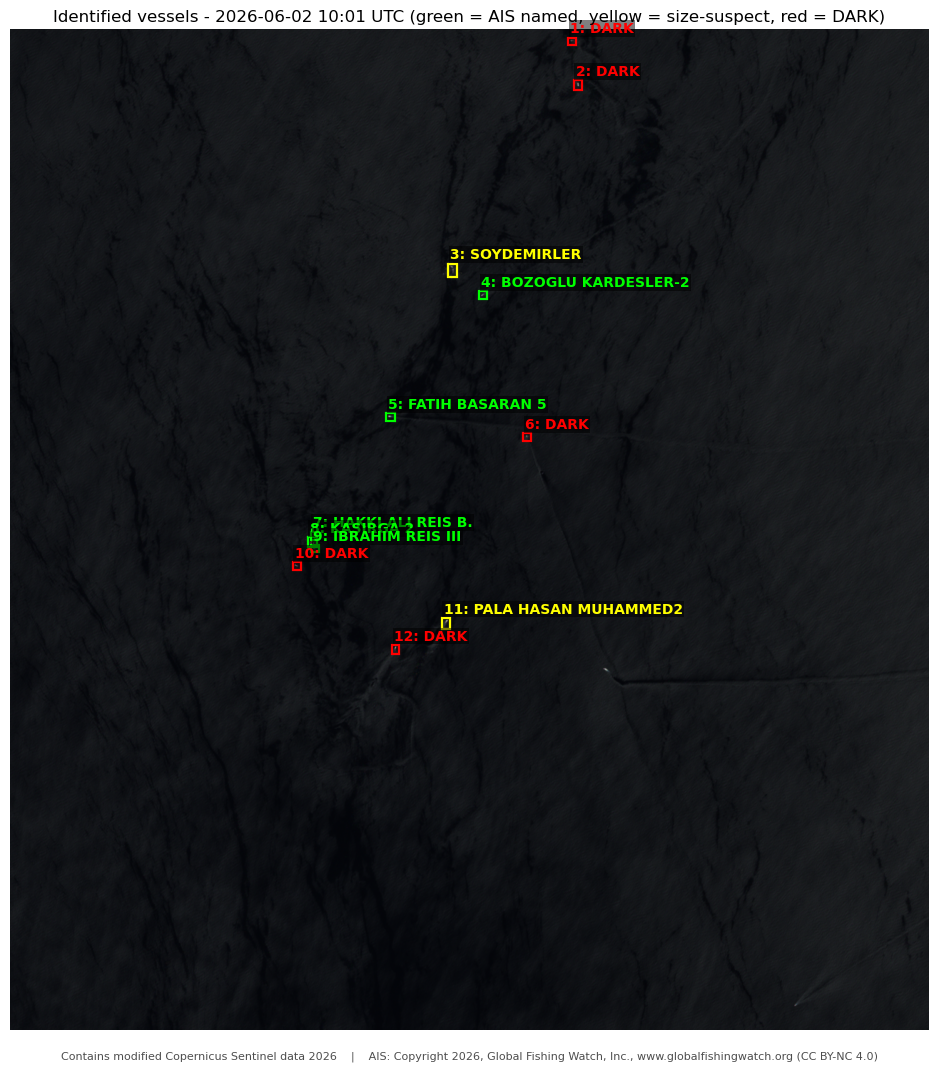

In [15]:
label_by_id = {r["id"]: r for r in results_rows}


def box_color(r):
    """red = DARK; yellow = matched but cluster oversized vs registry length; green = good match."""
    if r["dark"]:
        return "red"
    cl, gl = r.get("cluster_len_m"), r.get("gfw_len_m")
    if cl and gl:
        cluster_px = cl / resolution
        mismatch_px = (cl - gl) / resolution
        if cluster_px > 3 and mismatch_px > 6 and cl > 2 * gl:
            return "yellow"
    return "lime"


fig, ax = plt.subplots(figsize=(13, 13))
ax.imshow(falsecolor)
for _, d in sel_df.iterrows():
    r = label_by_id[int(d["id"])]
    color = box_color(r)
    wbox = d.col1 - d.col0 + 1
    hbox = d.row1 - d.row0 + 1
    ax.add_patch(
        patches.Rectangle(
            (d.col0 - 3, d.row0 - 3),
            wbox + 6,
            hbox + 6,
            fill=False,
            edgecolor=color,
            linewidth=1.6,
        )
    )
    ax.text(
        d.col0,
        d.row0 - 6,
        f"{int(d['id'])}: {r['label']}",
        color=color,
        fontsize=10,
        weight="bold",
        va="bottom",
        bbox=dict(facecolor="black", alpha=0.5, pad=1, edgecolor="none"),
    )
ax.set_title(
    f"Identified vessels - {ACQUISITION_DATE} {overpass_dt:%H:%M} UTC "
    f"(green = AIS named, yellow = size-suspect, red = DARK)"
)
ax.axis("off")

# Required data attributions (Copernicus Sentinel + Global Fishing Watch).
scene_year = ACQUISITION_DATE[:4]
attribution = (
    f"Contains modified Copernicus Sentinel data {scene_year}    |    "
    f"AIS: Copyright {scene_year}, Global Fishing Watch, Inc., "
    f"www.globalfishingwatch.org (CC BY-NC 4.0)"
)
ax.text(
    0.5,
    -0.02,
    attribution,
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=8,
    color="0.3",
)

out_png = f"ships_identified_{ACQUISITION_DATE}.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
print("Saved", out_png)
plt.show()

## 12. Export results

Save the results table next to the PNG for reporting.

In [16]:
csv_path = f"ships_identified_{ACQUISITION_DATE}.csv"
results_df.to_csv(csv_path, index=False)
print("Saved", csv_path)
results_df

Saved ships_identified_2026-06-02.csv


,id,lat,lon,label,dark,vessel_id,mmsi,flag,geartype,match_dist_m,cluster_len_m,gfw_len_m,len_ratio,size_ok
0,1,35.458361,13.242516,DARK,True,None,None,None,None,NaN,41.2,NaN,NaN,None
1,2,35.452764,13.243435,DARK,True,None,None,None,None,NaN,70.7,NaN,NaN,None
2,3,35.429049,13.224495,SOYDEMIRLER,False,b519b1443-3cff-3f0c-4725-b182e697e620,271056015,TUR,OTHER_PURSE_SEINES,420.8,117.0,49.9,2.34,True
3,4,35.425703,13.229028,BOZOGLU KARDESLER-2,False,6c50fe774-4a9d-41a2-83b1-fde2f50d07d9,271073083,TUR,OTHER_PURSE_SEINES,640.3,56.6,45.6,1.24,True
4,5,35.410069,13.214969,FATIH BASARAN 5,False,f42decb26-652f-5174-6a19-73313906c9fc,271072853,TUR,OTHER_PURSE_SEINES,456.0,53.9,43.3,1.24,True
5,6,35.407457,13.235687,DARK,True,None,None,None,None,NaN,44.7,NaN,NaN,None
6,7,35.394780,13.203418,HAKKI ALI REIS B.,False,7610206f8-8f73-f7e7-dc4f-02e01e224b93,271062039,TUR,OTHER_PURSE_SEINES,615.2,44.7,32.3,1.38,True
7,8,35.393916,13.203220,KASIRGA 2,False,6e91e3688-8040-44d8-d10e-11ac3e8ae31e,271073060,TUR,OTHER_PURSE_SEINES,753.2,76.2,38.6,1.97,True
8,9,35.393134,13.203632,IBRAHIM REIS III,False,c14e2576e-e12d-e155-7912-e218c81d864d,271072608,TUR,OTHER_PURSE_SEINES,674.3,50.0,46.8,1.07,True
9,10,35.390884,13.200799,DARK,True,None,None,None,None,NaN,50.0,NaN,NaN,None


## Attribution & licensing

**Satellite imagery — Copernicus Sentinel-2**, accessed via the Copernicus Data Space Ecosystem. Because the data is processed here, the required notice (per the [Copernicus Sentinel Data Legal Notice](https://sentinels.copernicus.eu/documents/247904/690755/Sentinel_Data_Legal_Notice)) is:

> Contains modified Copernicus Sentinel data [year of the scene]

**Vessel / AIS data — Global Fishing Watch**, via the GFW APIs, licensed under [CC BY-NC 4.0](https://creativecommons.org/licenses/by-nc/4.0/) (see the GFW [Terms of Use](https://globalfishingwatch.org/our-apis/documentation#terms-of-use)). Required citation:

> Copyright [year], Global Fishing Watch, Inc., www.globalfishingwatch.org.

Disclaimer (per GFW): *Global Fishing Watch has made every attempt to ensure the completeness, accuracy and reliability of the information provided on this Site.*

> **Note:** CC BY-NC 4.0 permits **non-commercial** use only. The final image in Section 11 embeds both attributions automatically (with the scene's year).